In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy

In [2]:
df = allanself.process_data('data/1610-771_dem.txt')
(df['RAcosDEC']/1000).describe()

count    360.000000
mean       1.317267
std       32.567085
min     -200.537610
25%       -0.718492
50%        0.000429
75%        0.662851
max      574.205509
Name: RAcosDEC, dtype: float64

In [3]:
df['Dec. (mas)'].describe()

count    360.000000
mean       1.690190
std       19.694882
min      -31.635198
25%       -0.699422
50%        0.005701
75%        0.742202
max      337.328302
Name: Dec. (mas), dtype: float64

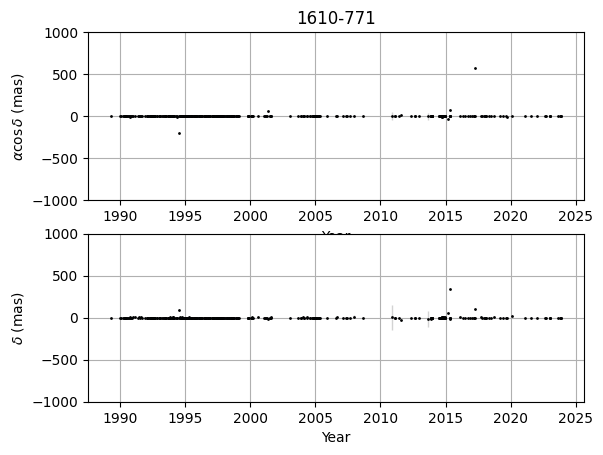

In [4]:
plt.subplot(211)
plt.title('1610-771')
plt.errorbar(df['BY'], df['RAcosDEC']/1000,yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [5]:
df_ra = allanself.remove_outliers(df,'RA')
df_dec= allanself.remove_outliers(df,'DEC')

c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\20 Samples\allanself.py:64: RuntimeWarning: invalid value encountered in scalar divide
  return sum(w[i]*(y[i]-ywbar)**2 for i in range(N))/((1-1/Np)*sum(w[i] for i in range(N)))


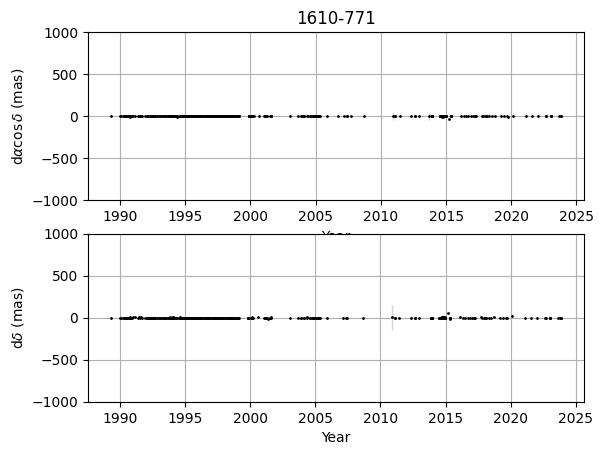

In [6]:
plt.subplot(211)
plt.title('1610-771')
plt.errorbar(df_ra['BY'], df_ra['RAcosDEC']/1000,yerr=df_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_dec['BY'], df_dec['Dec. (micas)']/1000, yerr=df_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

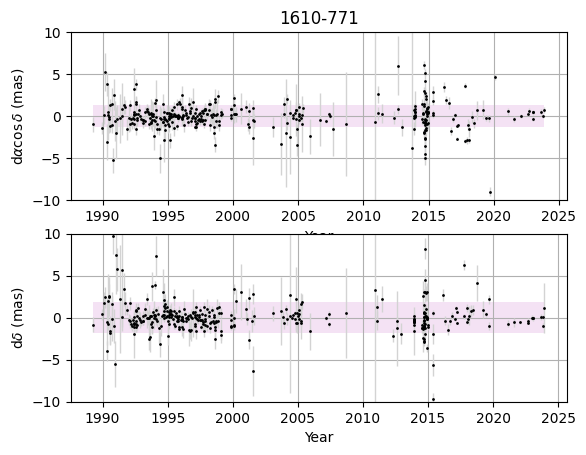

In [7]:
radec_std = np.sqrt(allanself.wvar(df_ra['RAcosDEC'].values/1000,1/(df_ra['Err. R.A. (micas)'].values/1000)**2))
dec_std = np.sqrt(allanself.wvar(df_dec['Dec. (micas)'].values/1000,1/(df_dec['Err. Dec. (micas)'].values/1000)**2))
plt.subplot(211)
plt.title('1610-771')
plt.errorbar(df_ra['BY'], df_ra['RAcosDEC']/1000,yerr=df_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.fill_between(df_ra['BY'], (-radec_std), (radec_std), facecolor='plum', alpha=0.3)
plt.ylim(-10,10)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_dec['BY'], df_dec['Dec. (micas)']/1000, yerr=df_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.fill_between(df_dec['BY'], (-dec_std), (dec_std), facecolor='plum', alpha=0.3)
plt.ylim(-10,10)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

In [8]:
%%time
tau_dec, allanstd_dec = allanself.oadev(df_dec['Dec. (micas)'].values,df_dec['MJD'].values,df_dec['Err. Dec. (micas)'].values)

CPU times: total: 1.34 s
Wall time: 2.11 s


In [9]:
%%time
tau_ra, allanstd_ra = allanself.oadev(df_ra['RAcosDEC'].values,df_ra['MJD'].values,df_ra['Err. R.A. (micas)'].values)

CPU times: total: 1.48 s
Wall time: 2.51 s


In [10]:
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_low, ci_dec_high = allanself.confidence_int(df_dec['Dec. (micas)'].values,df_dec['Err. Dec. (micas)'].values,allanstd_dec,modified=False,overlapping=True,devtype='allan')

In [11]:
ci_ra_low, ci_ra_high = allanself.confidence_int(df_ra['RAcosDEC'].values,df_ra['Err. R.A. (micas)'].values,allanstd_ra,modified=False,overlapping=True,devtype='allan')

In [12]:
tau_dec_year = np.array([x/365.242198781 for x in tau_dec])
tau_ra_year = np.array([x/365.242198781 for x in tau_ra])

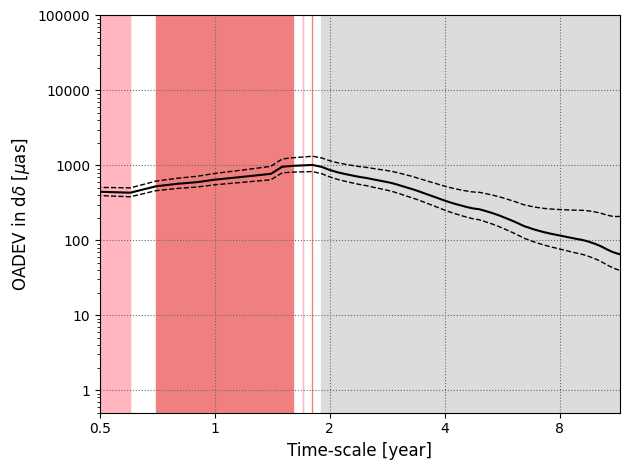

In [14]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (-0.25 <= slopes_dec) & (slopes_dec <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dec_year, ci_dec_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_year, ci_dec_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,max(tau_dec_year))
plt.tight_layout()

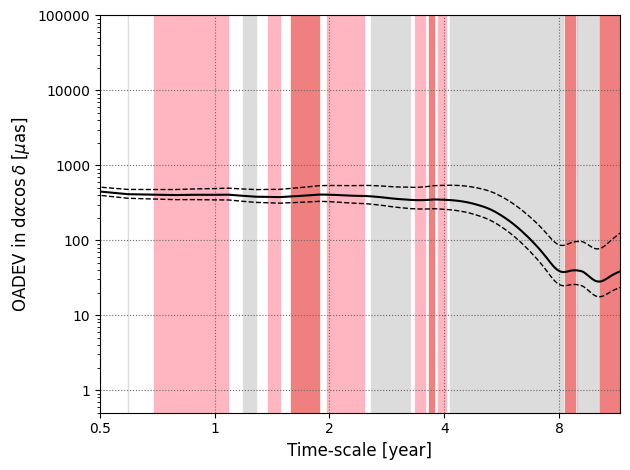

In [61]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(allanstd_ra)) / np.diff(np.log10(tau_ra))

# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (slopes_ra  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (-0.25 <= slopes_ra) & (slopes_ra <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (slopes_ra  > 0.25),color='lightcoral',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_year, ci_ra_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_year, ci_ra_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xlabel('Time-scale [year]', fontsize=12)
plt.xscale('log',base = 2)
plt.ylabel(r'OADEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.ylim(0.5,10**5)
plt.xlim(0.5,max(tau_ra_year))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.tight_layout()

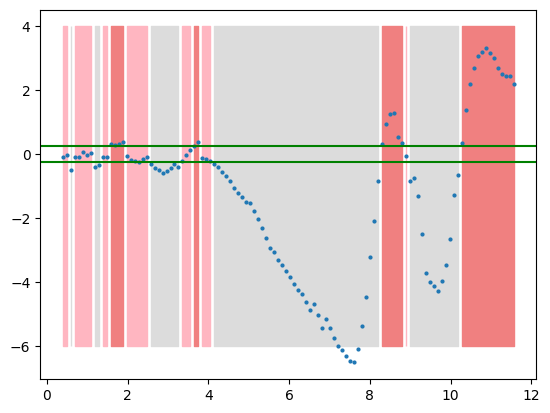

In [60]:
plt.fill_between(tau_ra_year[1:], -6, 4, (slopes_ra  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], -6, 4, (-0.25 <= slopes_ra) & (slopes_ra <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], -6, 4, (slopes_ra  > 0.25),color='lightcoral',linewidth=1.0,zorder=1)
plt.axhline(y=0.25,color='green')
plt.axhline(y=-0.25,color='green')

plt.scatter(tau_ra_year[1:],slopes_ra,s=4)
plt.show()


In [62]:
%%time
tau_dec_had, hadstd_dec = allanself.ohdev(df_dec['Dec. (micas)'].values,df_dec['MJD'].values,df_dec['Err. Dec. (micas)'].values)

c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\20 Samples\allanself.py:477: RuntimeWarning: invalid value encountered in scalar divide
  hadvar.append(np.sum(outersum)/(6*(M-3*m[k]+1-D)))


CPU times: total: 1.19 s
Wall time: 2.19 s


In [63]:
%%time
tau_ra_had, hadstd_ra = allanself.ohdev(df_ra['RAcosDEC'].values,df_ra['MJD'].values,df_ra['Err. R.A. (micas)'].values)

CPU times: total: 1.41 s
Wall time: 2.1 s


In [64]:
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_had_low, ci_dec_had_high = allanself.confidence_int(df_dec['Dec. (micas)'].values,df_dec['Err. Dec. (micas)'].values,hadstd_dec,modified=False,overlapping=True,devtype='hadamard')

In [65]:
ci_ra_had_low, ci_ra_had_high = allanself.confidence_int(df_ra['RAcosDEC'].values,df_ra['Err. R.A. (micas)'].values,hadstd_ra,modified=False,overlapping=True,devtype='hadamard')

In [66]:
tau_dec_had_year = np.array([x/365.242198781 for x in tau_dec_had])
tau_ra_had_year = np.array([x/365.242198781 for x in tau_ra_had])

C:\Users\Davendra\AppData\Local\Temp\ipykernel_7976\2127805437.py:3: RuntimeWarning: divide by zero encountered in log10
  slopes_dec_had = np.diff(np.log10(hadstd_dec)) / np.diff(np.log10(tau_dec_had))
C:\Users\Davendra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:1448: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


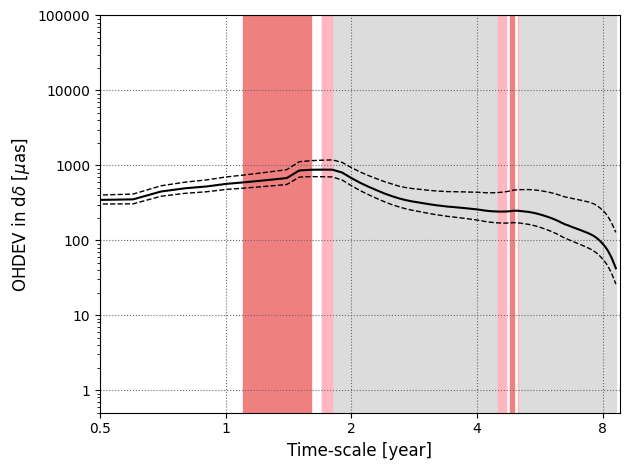

In [67]:
plt.figure()
# Calculate the slopes
slopes_dec_had = np.diff(np.log10(hadstd_dec)) / np.diff(np.log10(tau_dec_had))
# Plot hadamard std
plt.plot(tau_dec_had_year,hadstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (tau_dec_had_year[:-1] > 1) & (slopes_dec_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (tau_dec_had_year[:-1] > 1) & (-0.25 <= slopes_dec_had ) & (slopes_dec_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (tau_dec_had_year[:-1] > 1) & (slopes_dec_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_had_year, ci_dec_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_had_year, ci_dec_had_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OHDEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])
plt.tight_layout()

C:\Users\Davendra\AppData\Local\Temp\ipykernel_7976\3751605139.py:3: RuntimeWarning: divide by zero encountered in log10
  slopes_ra_had = np.diff(np.log10(hadstd_ra)) / np.diff(np.log10(tau_ra_had))


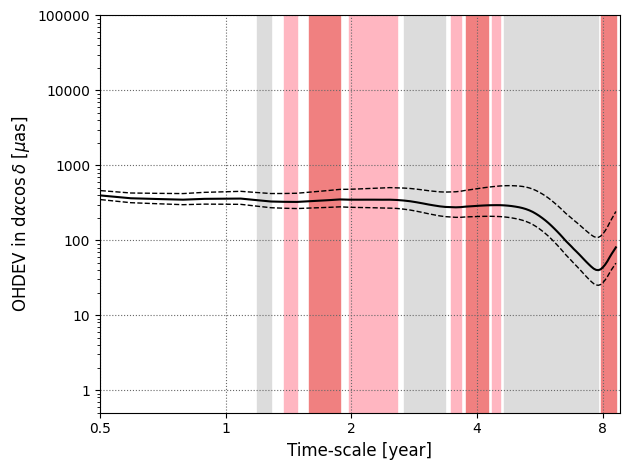

In [68]:
plt.figure()
# Calculate the slopes
slopes_ra_had = np.diff(np.log10(hadstd_ra)) / np.diff(np.log10(tau_ra_had))
# Plot hadamard
plt.plot(tau_ra_had_year,hadstd_ra,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (tau_ra_had_year[:-1] > 1) & (slopes_ra_had  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (tau_ra_had_year[:-1] > 1) & (-0.25 <= slopes_ra_had ) & (slopes_ra_had  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (tau_ra_had_year[:-1] > 1) & (slopes_ra_had  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_had_year, ci_ra_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_had_year, ci_ra_had_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xlabel('Time-scale [year]', fontsize=12)
plt.xscale('log',base = 2)
plt.ylabel(r'OHDEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_ra_had_year[np.count_nonzero(hadstd_ra)])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.tight_layout()

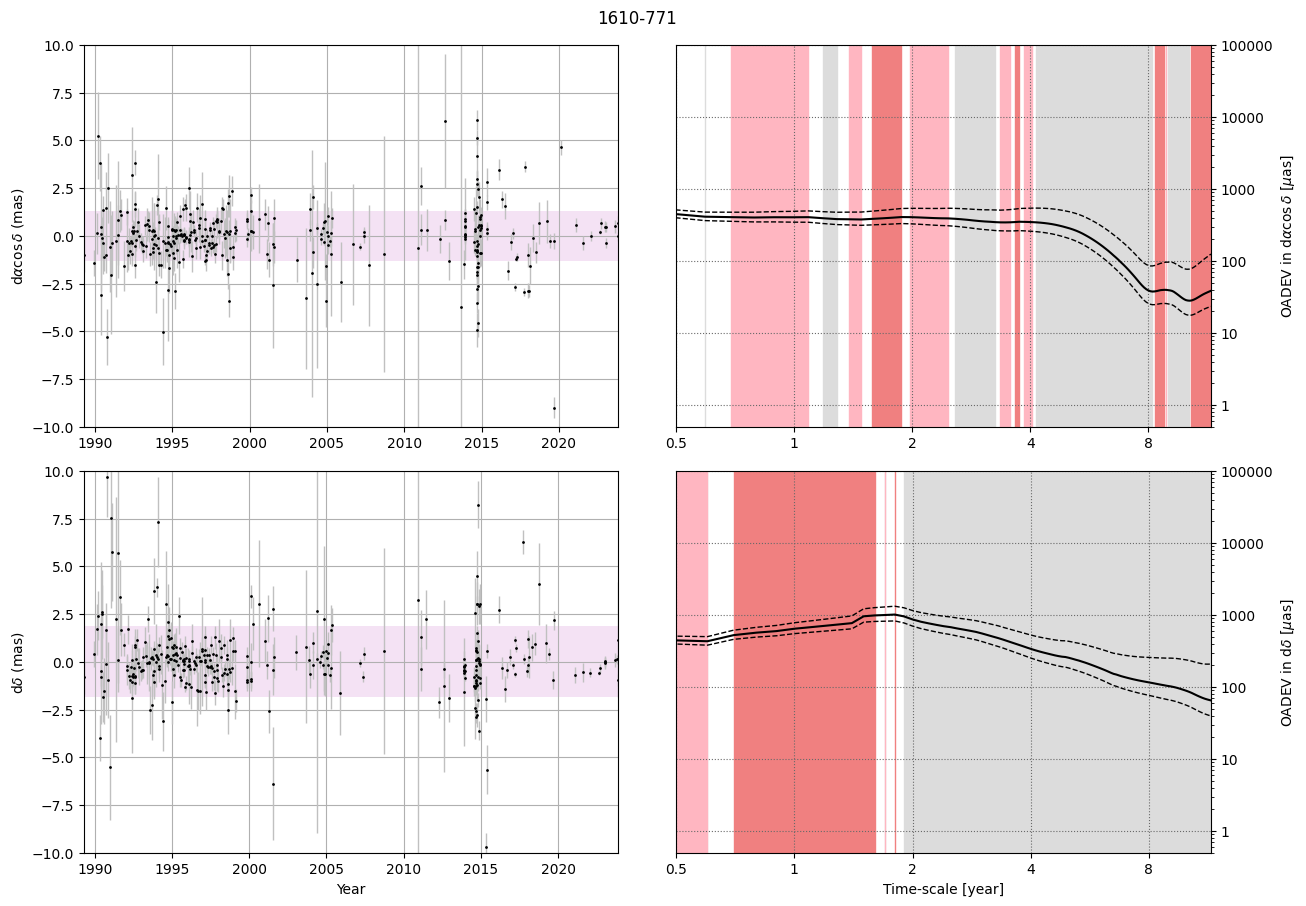

In [69]:
fig = plt.figure(figsize=(12,9))
fig.add_subplot(221)   #top left
fig.add_subplot(222)   #top right
fig.add_subplot(223)   #bottom left
fig.add_subplot(224)   #bottom right 


fig.suptitle('1610-771')

plt.tight_layout()

plt.subplot(221)
plt.errorbar(df_ra['BY'], df_ra['RAcosDEC']/1000,yerr=df_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='silver', elinewidth=1)
plt.fill_between(df_ra['BY'], (-radec_std), (radec_std), facecolor='plum', alpha=0.3)
plt.ylim(-10,10)
plt.xlim(min(df_ra['BY']),max(df_ra['BY']))
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()

plt.subplot(222)
# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (slopes_ra  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (slopes_ra  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_year, ci_ra_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_year, ci_ra_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylabel(r'OADEV in d$\alpha \cos \delta$ [$\mu$as]')
plt.ylim(0.5,10**5)
plt.xlim(0.5,max(tau_ra_year))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().yaxis.set_label_position("right")
plt.gca().yaxis.tick_right()


plt.subplot(224)
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (-0.25 <= slopes_dec) & (slopes_dec <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dec_year, ci_dec_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_year, ci_dec_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]')
plt.ylabel(r'OADEV in d$\delta$ [$\mu$as]')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,max(tau_dec_year))
plt.gca().yaxis.set_label_position("right")
plt.gca().yaxis.tick_right()



plt.subplot(223)
plt.errorbar(df_dec['BY'], df_dec['Dec. (micas)']/1000, yerr=df_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='silver', elinewidth=1)
plt.fill_between(df_dec['BY'], (-dec_std), (dec_std), facecolor='plum', alpha=0.3)
plt.ylim(-10,10)
plt.xlim(min(df_dec['BY']),max(df_dec['BY']))
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()



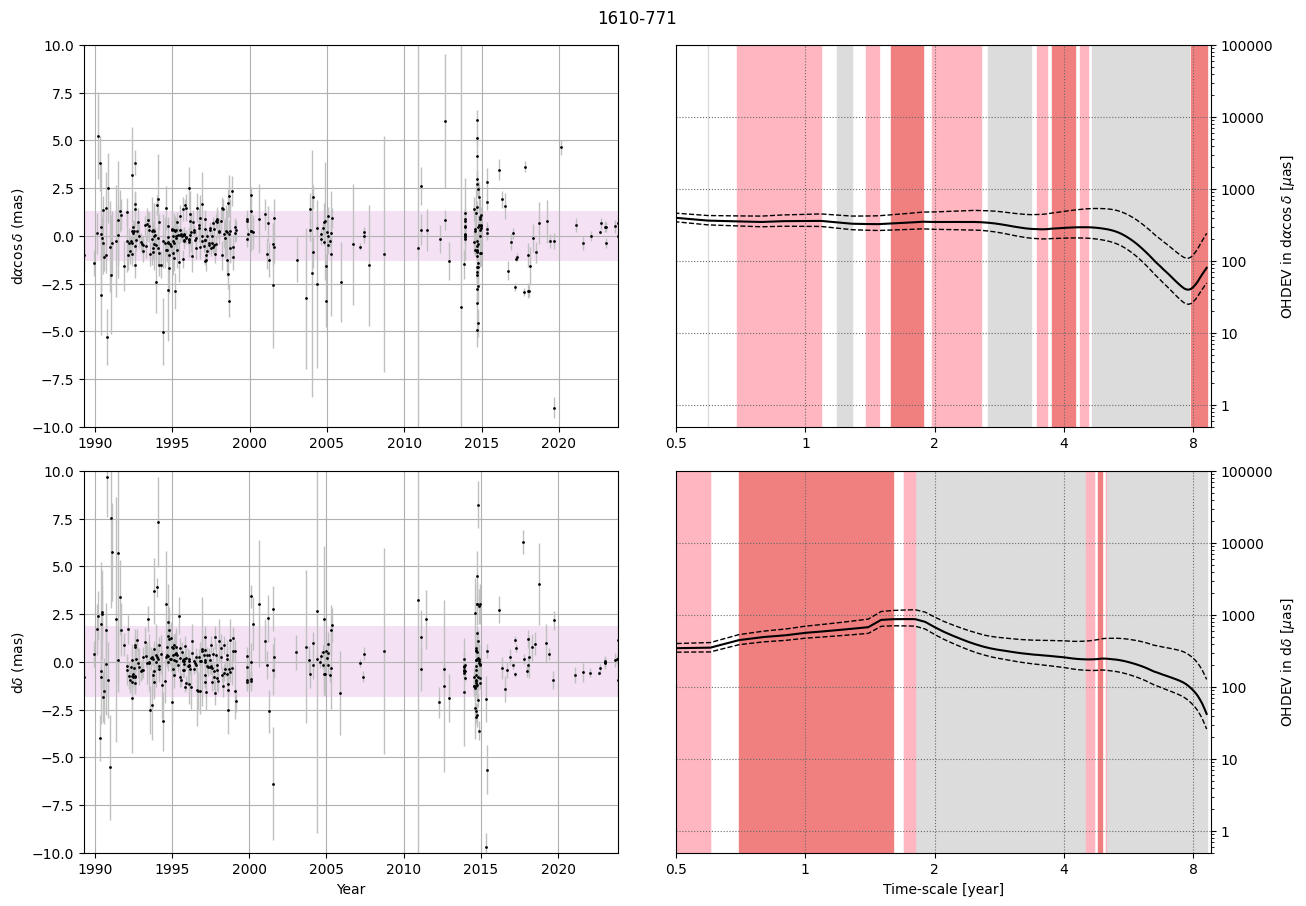

In [70]:
fig = plt.figure(figsize=(12,9))
fig.add_subplot(221)   #top left
fig.add_subplot(222)   #top right
fig.add_subplot(223)   #bottom left
fig.add_subplot(224)   #bottom right 


fig.suptitle('1610-771')

plt.tight_layout()

plt.subplot(221)
plt.errorbar(df_ra['BY'], df_ra['RAcosDEC']/1000,yerr=df_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='silver', elinewidth=1)
plt.fill_between(df_ra['BY'], (-radec_std), (radec_std), facecolor='plum', alpha=0.3)
plt.ylim(-10,10)
plt.xlim(min(df_ra['BY']),max(df_ra['BY']))
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()

plt.subplot(222)
# Plot hadamard
plt.plot(tau_ra_had_year,hadstd_ra,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (slopes_ra_had  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (-0.25 <= slopes_ra_had ) & (slopes_ra_had  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (slopes_ra_had  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_had_year, ci_ra_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_had_year, ci_ra_had_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylabel(r'OHDEV in d$\alpha \cos \delta$ [$\mu$as]')
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_ra_had_year[np.count_nonzero(hadstd_ra)])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().yaxis.set_label_position("right")
plt.gca().yaxis.tick_right()




plt.subplot(224)
# Plot hadamard std
plt.plot(tau_dec_had_year,hadstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (slopes_dec_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (-0.25 <= slopes_dec_had ) & (slopes_dec_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (slopes_dec_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_had_year, ci_dec_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_had_year, ci_dec_had_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]')
plt.ylabel(r'OHDEV in d$\delta$ [$\mu$as]')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])
plt.gca().yaxis.set_label_position("right")
plt.gca().yaxis.tick_right()



plt.subplot(223)
plt.errorbar(df_dec['BY'], df_dec['Dec. (micas)']/1000, yerr=df_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='silver', elinewidth=1)
plt.fill_between(df_dec['BY'], (-dec_std), (dec_std), facecolor='plum', alpha=0.3)
plt.ylim(-10,10)
plt.xlim(min(df_dec['BY']),max(df_dec['BY']))
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()



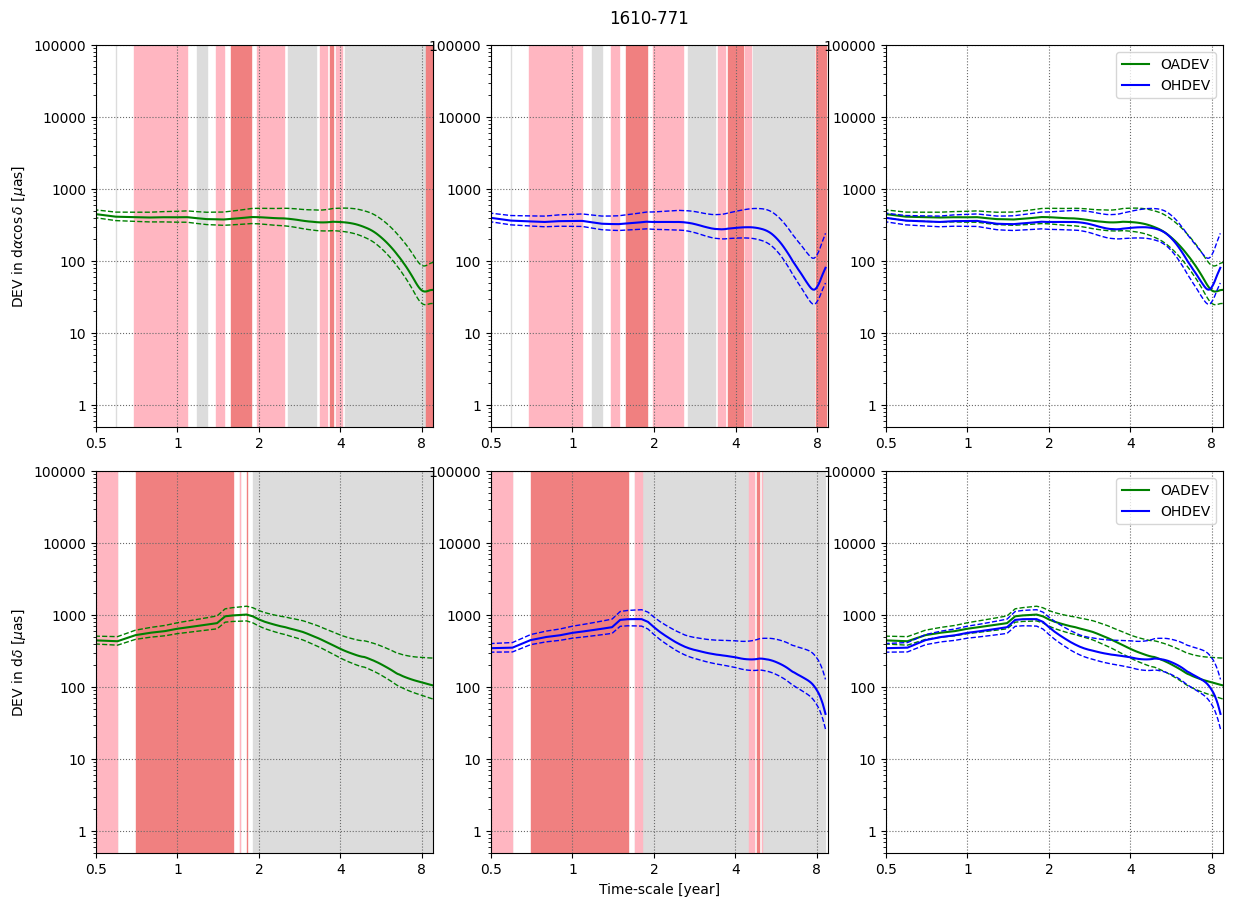

In [71]:
fig = plt.figure(figsize=(12,9))
fig.add_subplot(231)   
fig.add_subplot(232)  
fig.add_subplot(233)   
fig.add_subplot(234)  
fig.add_subplot(235) 
fig.add_subplot(236) 


fig.suptitle('1610-771')

plt.tight_layout()

plt.subplot(231)
# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra,color='green',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (slopes_ra  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**5, (slopes_ra  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_year, ci_ra_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_year, ci_ra_high,color='green',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylabel(r'DEV in d$\alpha \cos \delta$ [$\mu$as]')
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

plt.subplot(232)
# Plot hadamard
plt.plot(tau_ra_had_year,hadstd_ra,color='blue',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (slopes_ra_had  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (-0.25 <= slopes_ra_had ) & (slopes_ra_had  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**5, where= (slopes_ra_had  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_had_year, ci_ra_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_had_year, ci_ra_had_high,color='blue',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_ra_had_year[np.count_nonzero(hadstd_ra)])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))


plt.subplot(233)
plt.grid(color='dimgray',linestyle='dotted')
# Plot OADEV and CIs
plt.plot(tau_ra_had_year,allanstd_ra,color='green',label='OADEV')
plt.plot(tau_ra_had_year, ci_ra_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_had_year, ci_ra_high,color='green',linestyle='dashed',linewidth=1)

# Plot OHDEV and CIs
plt.plot(tau_ra_had_year,hadstd_ra,color='blue',label='OHDEV')
plt.plot(tau_ra_had_year, ci_ra_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_had_year, ci_ra_had_high,color='blue',linestyle='dashed',linewidth=1)

plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])
plt.ylim(0.5,10**5)
plt.xscale('log',base = 2)
plt.yscale('log')
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

plt.subplot(236)
plt.grid(color='dimgray',linestyle='dotted')
# Plot OADEV and CIs
plt.plot(tau_dec_year,allanstd_dec,color='green',label='OADEV')
plt.plot(tau_dec_year, ci_dec_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_year, ci_dec_high,color='green',linestyle='dashed',linewidth=1)
# Plot OHDEV and CIs
plt.plot(tau_dec_had_year,hadstd_dec,color='blue',label='OHDEV')
plt.plot(tau_dec_had_year, ci_dec_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_had_year, ci_dec_had_high,color='blue',linestyle='dashed',linewidth=1)
plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])
plt.ylim(0.5,10**5)
plt.xscale('log',base = 2)
plt.yscale('log')
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))


plt.subplot(235)
# Plot hadamard std
plt.plot(tau_dec_had_year,hadstd_dec,color='blue',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (slopes_dec_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (-0.25 <= slopes_dec_had ) & (slopes_dec_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**5, (slopes_dec_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_had_year, ci_dec_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_had_year, ci_dec_had_high,color='blue',linestyle='dashed',linewidth=1)
plt.xlabel('Time-scale [year]')
plt.yscale('log')
plt.xscale('log',base = 2)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])


plt.subplot(234)
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='green',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (-0.25 <= slopes_dec) & (slopes_dec <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dec_year, ci_dec_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_year, ci_dec_high,color='green',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylabel(r'DEV in d$\delta$ [$\mu$as]')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,tau_dec_had_year[np.count_nonzero(hadstd_dec)])
plt.show()




